In [1]:
from quam_libs.json_saver import load_from_npz_json

Markovian_data = load_from_npz_json(
    npz_path="data/analyze_data/markovian_arrays.npz",
    json_path="data/analyze_data/markovian.json",
)

non_Markovian_data = load_from_npz_json(
    npz_path="data/analyze_data/non_markovian_arrays.npz",
    json_path="data/analyze_data/non_markovian.json",
)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
nonMarkovian_axes_list = np.array([non_Markovian_data['raw'][key]['ellipsoid']['axes'] for key in non_Markovian_data['raw'].keys()])
nonMarkovian_robustness_list = np.array([non_Markovian_data['raw'][key]['quantum_information']['robustness'] for key in non_Markovian_data['raw'].keys()])
sim_nonMarkovian_robustness_list = np.array([non_Markovian_data['sim_raw'][key]['quantum_information']['robustness'] for key in non_Markovian_data['sim_raw'].keys()])
interaction_time = np.array([int(key.split('=')[1].split('ns')[0]) for key in non_Markovian_data['raw'].keys()])

Markovian_axes_list = np.array([Markovian_data['raw'][key]['ellipsoid']['axes'] for key in Markovian_data['raw'].keys()])
Markovian_robustness_list = np.array([Markovian_data['raw'][key]['quantum_information']['robustness'] for key in Markovian_data['raw'].keys()])
sim_Markovian_robustness_list = np.array([Markovian_data['sim_raw'][key]['quantum_information']['robustness'] for key in Markovian_data['sim_raw'].keys()])
raw_dephasing_rates = np.array([Markovian_data['raw'][key]['qubit_properties']['dephasing_rate'] for key in Markovian_data['raw'].keys()])*1e-6
sim_dephasing_rates =  np.array([Markovian_data['sim_raw'][key]['qubit_properties']['dephasing_rate'] for key in Markovian_data['sim_raw'].keys()])*1e-6
fit_dephasing_rates = Markovian_data['raw_fit']['dephasing_rate']*1e-6
fit_raw_axes_x = Markovian_data['raw_fit']['x_axis_fit']
fit_raw_axes_y = Markovian_data['raw_fit']['y_axis_fit']
fit_raw_axes_z = Markovian_data['raw_fit']['z_axis_fit']*np.ones_like(fit_dephasing_rates)

Text(-0.15, 1.03, '(d)')

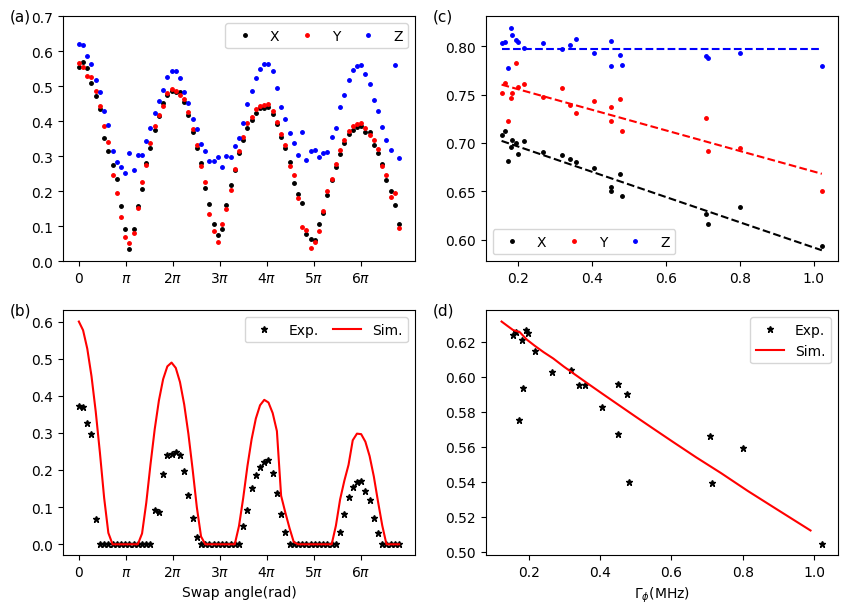

In [4]:
fig = plt.figure(figsize=(10, 7))
ax_nonMarkovian_axes = fig.add_subplot(2, 2, 1)
ax_nonMarkovian_robustness = fig.add_subplot(2, 2, 3)
ax_Markovian_axes = fig.add_subplot(2, 2, 2)
ax_Markovian_robustness = fig.add_subplot(2, 2, 4)

coupling_mhz = 44.8
pi_time_ns = 1000 / coupling_mhz
max_time_ns = 150
max_pi = int(max_time_ns / pi_time_ns)  

xticks_positions = [i * pi_time_ns for i in range(max_pi + 1)]
xticks_labels = ["0"] + [(f"{i}$\\pi$" if i > 1 else "$\\pi$") for i in range(1, max_pi + 1)]

ax_nonMarkovian_axes.plot(interaction_time, nonMarkovian_axes_list[:, 0], '.', color='black', markersize=5, label='X')
ax_nonMarkovian_axes.plot(interaction_time, nonMarkovian_axes_list[:, 1], '.', color='red', markersize=5, label='Y')
ax_nonMarkovian_axes.plot(interaction_time, nonMarkovian_axes_list[:, 2], '.', color='blue', markersize=5, label='Z')
ax_nonMarkovian_axes.set_xticks(xticks_positions)
ax_nonMarkovian_axes.set_xticklabels(xticks_labels)
ax_nonMarkovian_axes.set_ylim(0,0.7)
ax_nonMarkovian_axes.legend(loc='upper right', ncol=3, columnspacing=1.0)    
ax_nonMarkovian_axes.text(-0.15, 1.03, "(a)", transform=ax_nonMarkovian_axes.transAxes,ha="left", va="top", fontsize=11)

ax_nonMarkovian_robustness.plot(interaction_time, nonMarkovian_robustness_list, '*', color='black', markersize=5, label='Exp.')
ax_nonMarkovian_robustness.plot(interaction_time, sim_nonMarkovian_robustness_list, '-', color='red', label='Sim.')
ax_nonMarkovian_robustness.set_xticks(xticks_positions)
ax_nonMarkovian_robustness.set_xticklabels(xticks_labels)
ax_nonMarkovian_robustness.set_xlabel('Swap angle(rad)')
ax_nonMarkovian_robustness.legend(loc='upper right', ncol=2, columnspacing=1.0)
ax_nonMarkovian_robustness.text(-0.15, 1.03, "(b)", transform=ax_nonMarkovian_robustness.transAxes,ha="left", va="top", fontsize=11)

ax_Markovian_axes.plot(raw_dephasing_rates, Markovian_axes_list[:, 0], '.', color='black', markersize=5, label='X')
ax_Markovian_axes.plot(raw_dephasing_rates, Markovian_axes_list[:, 1], '.', color='red', markersize=5, label='Y')
ax_Markovian_axes.plot(raw_dephasing_rates, Markovian_axes_list[:, 2], '.', color='blue', markersize=5, label='Z')
ax_Markovian_axes.plot(fit_dephasing_rates, fit_raw_axes_x,linestyle='dashed',color='k')
ax_Markovian_axes.plot(fit_dephasing_rates, fit_raw_axes_y,linestyle='dashed',color='red')
ax_Markovian_axes.plot(fit_dephasing_rates, fit_raw_axes_z,linestyle='dashed',color='blue')
ax_Markovian_axes.legend(loc='lower left', ncol=3, columnspacing=1.0)    
ax_Markovian_axes.text(-0.15, 1.03, "(c)", transform=ax_Markovian_axes.transAxes,ha="left", va="top", fontsize=11)

ax_Markovian_robustness.plot(raw_dephasing_rates, Markovian_robustness_list, '*', color='black', markersize=5, label='Exp.')
ax_Markovian_robustness.plot(sim_dephasing_rates, sim_Markovian_robustness_list, '-', color='red', label='Sim.')
ax_Markovian_robustness.set_xlabel('$\\Gamma_\\phi$(MHz)')
ax_Markovian_robustness.legend(loc='upper right')
ax_Markovian_robustness.text(-0.15, 1.03, "(d)", transform=ax_Markovian_robustness.transAxes,ha="left", va="top", fontsize=11)
# plt.savefig('paper_figure/AppendixD.pdf', dpi=600,bbox_inches='tight')

In [5]:
from scipy.stats import pearsonr

sorted_Markovian_robustness_list = np.sort(Markovian_robustness_list)
sorted_sim_Markovian_robustness_list = np.sort(sim_Markovian_robustness_list)
r,p_value = pearsonr(sorted_Markovian_robustness_list, sorted_sim_Markovian_robustness_list)
r_squared = r**2
print("Pearson r =", r)
print("Pearson r^2 =", r_squared)
print("p-value =", p_value)

Pearson r = 0.9824656589930045
Pearson r^2 = 0.9652387711005587
p-value = 2.536272011395871e-15
